In [ ]:
Dataset choisi : Heart Disease (UCI ML Repo) 
- Lien : https://archive.ics.uci.edu/dataset/45/heart+disease
Problème : Classification supervisée binaire 
- Variable cible num : 0 = absence de maladie cardiaque, 1 = présence de maladie cardiaque - Type d’apprentissage : Apprentissage supervisé
Le problème est une classification supervisée binaire car la cible num indique la présence (1) ou l’absence (0) de maladie cardiaque et les labels 
sont connus.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo


In [2]:
pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.


In [3]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
heart_disease = fetch_ucirepo(id=45) 
  
# data (as pandas dataframes) 
X = heart_disease.data.features 
y = heart_disease.data.targets 
  
# metadata 
print(heart_disease.metadata) 
  
# variable information 
print(heart_disease.variables) 


{'uci_id': 45, 'name': 'Heart Disease', 'repository_url': 'https://archive.ics.uci.edu/dataset/45/heart+disease', 'data_url': 'https://archive.ics.uci.edu/static/public/45/data.csv', 'abstract': '4 databases: Cleveland, Hungary, Switzerland, and the VA Long Beach', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 303, 'num_features': 13, 'feature_types': ['Categorical', 'Integer', 'Real'], 'demographics': ['Age', 'Sex'], 'target_col': ['num'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1989, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C52P4X', 'creators': ['Andras Janosi', 'William Steinbrunn', 'Matthias Pfisterer', 'Robert Detrano'], 'intro_paper': {'ID': 231, 'type': 'NATIVE', 'title': 'International application of a new probability algorithm for the diagnosis of coronary artery disease.', 'authors': 'R. Detrano, A. Jánosi, W. Steinbrunn, M

In [4]:
df = pd.concat([X, y], axis=1)

In [5]:
df.shape


(303, 14)

In [6]:
df.columns


Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='object')

In [7]:
df.dtypes


age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca          float64
thal        float64
num           int64
dtype: object

In [8]:
df.isnull().sum()


age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
num         0
dtype: int64

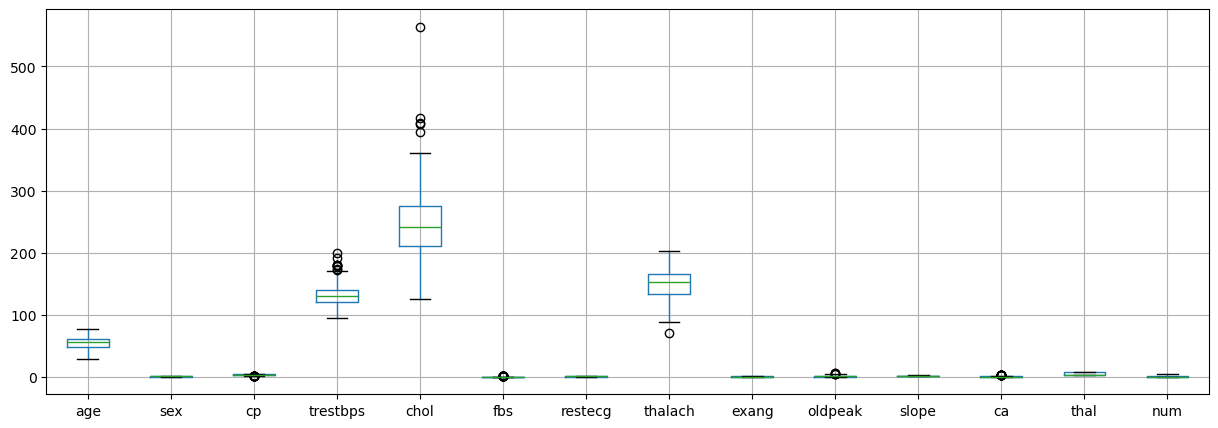

In [9]:
df.boxplot(figsize=(15,5))
plt.show()



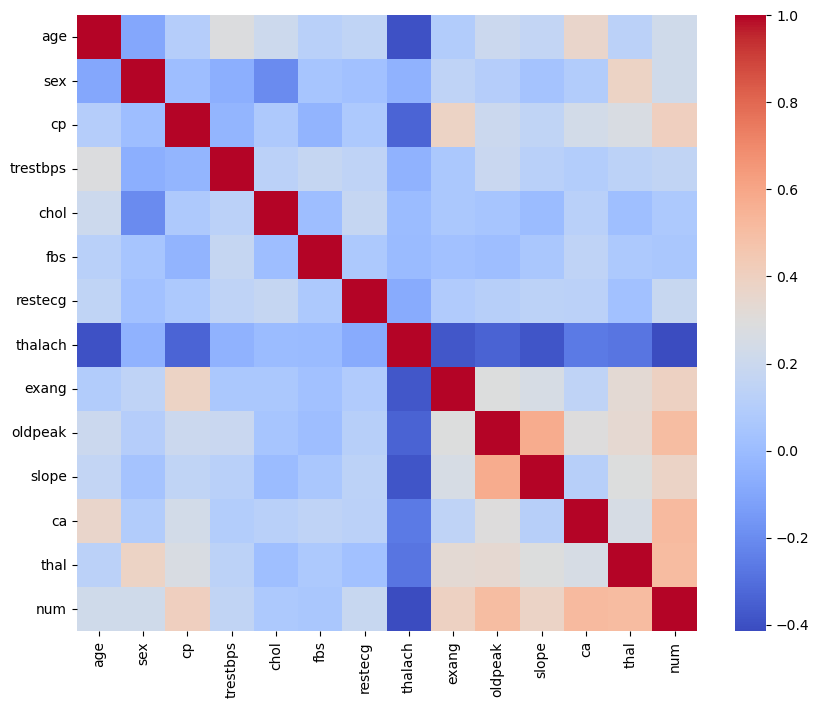

In [10]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.show()


In [11]:
df['num'] = df['num'].apply(lambda x: 0 if x == 0 else 1)


In [12]:
df['ca'] = df['ca'].fillna(df['ca'].median())
df['thal'] = df['thal'].fillna(df['thal'].mode()[0])


In [13]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64

In [14]:
df = pd.get_dummies(
    df,
    columns=['sex','cp','fbs','restecg','exang','slope','thal'],
    drop_first=True
)


In [15]:
df.columns


Index(['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca', 'num', 'sex_1',
       'cp_2', 'cp_3', 'cp_4', 'fbs_1', 'restecg_1', 'restecg_2', 'exang_1',
       'slope_2', 'slope_3', 'thal_6.0', 'thal_7.0'],
      dtype='object')

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
num_cols = ['age','trestbps','chol','thalach','oldpeak','ca']
df[num_cols] = scaler.fit_transform(df[num_cols])


In [17]:
from sklearn.model_selection import train_test_split

X = df.drop('num', axis=1)
y = df['num']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [18]:
print("X :", X.shape)
print("X_train :", X_train.shape)
print("X_test :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test :", y_test.shape)


X : (303, 18)
X_train : (242, 18)
X_test : (61, 18)
y_train : (242,)
y_test : (61,)


In [19]:
df[num_cols].mean()


age        -1.465641e-18
trestbps    4.426236e-16
chol        2.345026e-16
thalach    -1.172513e-16
oldpeak     2.345026e-17
ca         -4.690051e-17
dtype: float64

In [20]:
df[num_cols].std()


age         1.001654
trestbps    1.001654
chol        1.001654
thalach     1.001654
oldpeak     1.001654
ca          1.001654
dtype: float64

In [21]:
df[num_cols].describe()

,age,trestbps,chol,thalach,oldpeak,ca
count,3.030000e+02,3.030000e+02,3.030000e+02,3.030000e+02,3.030000e+02,3.030000e+02
mean,-1.465641e-18,4.426236e-16,2.345026e-16,-1.172513e-16,2.345026e-17,-4.690051e-17
std,1.001654e+00,1.001654e+00,1.001654e+00,1.001654e+00,1.001654e+00,1.001654e+00
min,-2.819115e+00,-2.145037e+00,-2.334877e+00,-3.442067e+00,-8.968617e-01,-7.111314e-01
25%,-7.135564e-01,-6.652997e-01,-6.905030e-01,-7.053073e-01,-8.968617e-01,-7.111314e-01
50%,1.729945e-01,-9.616980e-02,-1.101357e-01,1.485618e-01,-2.067053e-01,-7.111314e-01
75%,7.270888e-01,4.729601e-01,5.476139e-01,7.178079e-01,4.834512e-01,3.608726e-01
max,2.500191e+00,3.887739e+00,6.138485e+00,2.294182e+00,4.451851e+00,2.504881e+00


In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, zero_division=0))


Accuracy : 0.8524590163934426
              precision    recall  f1-score   support

           0       0.90      0.82      0.86        33
           1       0.81      0.89      0.85        28

    accuracy                           0.85        61
   macro avg       0.85      0.86      0.85        61
weighted avg       0.86      0.85      0.85        61



In [23]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
print("Accuracy RF :", accuracy_score(y_test, y_pred_rf))


Accuracy RF : 0.9016393442622951


In [24]:
from sklearn.model_selection import GridSearchCV

params = {
    "n_estimators": [50, 100],
    "max_depth": [None, 5, 10]
}

grid = GridSearchCV(RandomForestClassifier(random_state=42),
                    params, cv=5)
grid.fit(X_train, y_train)

print("Meilleurs paramètres :", grid.best_params_)


Meilleurs paramètres : {'max_depth': 5, 'n_estimators': 100}


In [25]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf, X, y, cv=5)
print("Score moyen CV :", scores.mean())


Score moyen CV : 0.8281967213114754


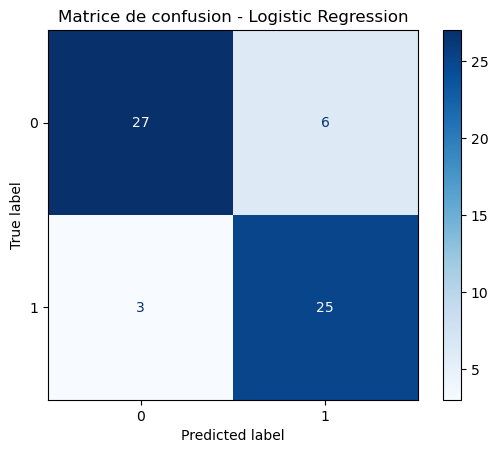

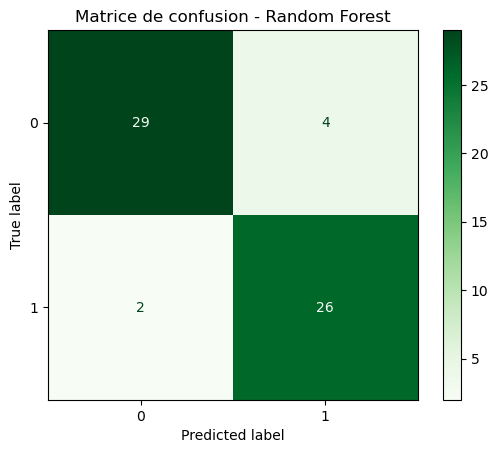

In [26]:
from sklearn.metrics import ConfusionMatrixDisplay

# Pour Logistic Regression
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues')
plt.title("Matrice de confusion - Logistic Regression")
plt.show()

# Pour Random Forest
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, cmap='Greens')
plt.title("Matrice de confusion - Random Forest")
plt.show()
